In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf
import datetime

In [2]:
bist100_1h = yf.download("XU100.IS", interval="1h", period="max", multi_level_index=False)

$XU100.IS: possibly delisted; no price data found  (1h 2024-10-07 20:59:30+03:00 -> 2026-10-07 20:59:25+03:00) (Yahoo error = "1h data not available for startTime=1728323970 and endTime=1791395965. The requested range must be within the last 730 days.")
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['XU100.IS']: possibly delisted; no price data found  (1h 2024-10-07 20:59:30+03:00 -> 2026-10-07 20:59:25+03:00) (Yahoo error = "1h data not available for startTime=1728323970 and endTime=1791395965. The requested range must be within the last 730 days.")


In [3]:
bist100_1h.index = bist100_1h.index.tz_convert("Europe/Istanbul")

In [4]:
bist100_1h

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,


In [5]:
bist100_1h["return_1h"] = bist100_1h["Close"].pct_change()

In [6]:
daily_rv = bist100_1h["return_1h"].pow(2).resample("1D").sum(min_count=1).pow(0.5)

In [8]:
daily_rv = pd.DataFrame(daily_rv)

In [9]:
daily_rv = daily_rv.rename(columns={
    "return_1h": "daily_rv"
})

In [10]:
daily_rv

,daily_rv
Date,


In [11]:
daily_rv.dropna(inplace=True)

In [12]:
daily_rv

,daily_rv
Date,


In [13]:
lower_bound = daily_rv["daily_rv"].rolling(20).quantile(0.33)
upper_bound = daily_rv["daily_rv"].rolling(20).quantile(0.67)
rv = daily_rv["daily_rv"]

In [14]:
daily_rv["volatility_regime"] = np.select(
    [
        rv < lower_bound,
        rv > upper_bound
    ],
    [   "low_volatility",
        "high_volatility"
    ],
    default="neutral"
)

daily_rv.loc[lower_bound.isnull() | upper_bound.isnull(), "volatility_regime"] = "insufficient_history"

In [15]:
daily_rv

,daily_rv,volatility_regime
Date,,


In [38]:
def realized_volatility(df, interval: str, rolling_period: int, timezone):
    df.index = df.index.tz_convert(timezone)
    df["return"] = df["Close"].pct_change()
    daily_rv = df["return"].pow(2).resample("1D").sum(min_count=1).pow(0.5)
    daily_rv = pd.DataFrame(daily_rv)
    column = daily_rv.columns.to_list()[0]
    daily_rv = daily_rv.rename(columns={column: "daily_rv"})
    daily_rv["return"] = df["return"].resample("1D").sum(min_count=1)
    daily_rv.dropna(inplace=True)

    lower_bound = daily_rv["daily_rv"].rolling(rolling_period).quantile(0.33)
    upper_bound = daily_rv["daily_rv"].rolling(rolling_period).quantile(0.67)
    rv = daily_rv["daily_rv"]

    daily_rv["volatility_regime"] = np.select(
    [
        rv < lower_bound,
        rv > upper_bound
    ],
    [   "low_volatility",
        "high_volatility"
    ],
    default="neutral"
    )
    daily_rv.loc[lower_bound.isnull() | upper_bound.isnull(), "volatility_regime"] = "insufficient_history"

    return daily_rv

    

In [39]:
thyao_1h = yf.download("THYAO.IS", period="max", interval="1h", multi_level_index=False)

[*********************100%***********************]  1 of 1 completed


In [40]:
thyao_rv = realized_volatility(thyao_1h, "1h", 20, timezone="Europe/Istanbul")

In [41]:
thyao_rv

,daily_rv,return,volatility_regime
Datetime,,,
2024-10-08 00:00:00+03:00,0.014794,0.001961,insufficient_history
2024-10-09 00:00:00+03:00,0.014651,0.001032,insufficient_history
2024-10-10 00:00:00+03:00,0.008044,-0.013928,insufficient_history
2024-10-11 00:00:00+03:00,0.013367,-0.008381,insufficient_history
2024-10-14 00:00:00+03:00,0.012543,-0.023834,insufficient_history
...,...,...,...
2026-10-01 00:00:00+03:00,0.022094,0.011651,high_volatility
2026-10-02 00:00:00+03:00,0.012519,0.019949,low_volatility
2026-10-05 00:00:00+03:00,0.008572,0.000892,low_volatility


In [42]:
tuprs_1h = yf.download("TUPRS.IS", period="max", interval="1h", multi_level_index=False)

[*********************100%***********************]  1 of 1 completed


In [43]:
tuprs_rv = realized_volatility(tuprs_1h, interval="1h", rolling_period=20, timezone="Europe/Istanbul")

In [44]:
tuprs_rv

,daily_rv,return,volatility_regime
Datetime,,,
2024-10-08 00:00:00+03:00,0.016103,0.013896,insufficient_history
2024-10-09 00:00:00+03:00,0.016363,-0.005742,insufficient_history
2024-10-10 00:00:00+03:00,0.008676,-0.019136,insufficient_history
2024-10-11 00:00:00+03:00,0.011981,-0.011341,insufficient_history
2024-10-14 00:00:00+03:00,0.007942,-0.015620,insufficient_history
...,...,...,...
2026-10-01 00:00:00+03:00,0.023249,0.025123,neutral
2026-10-02 00:00:00+03:00,0.035408,-0.026206,high_volatility
2026-10-05 00:00:00+03:00,0.027731,0.033663,neutral


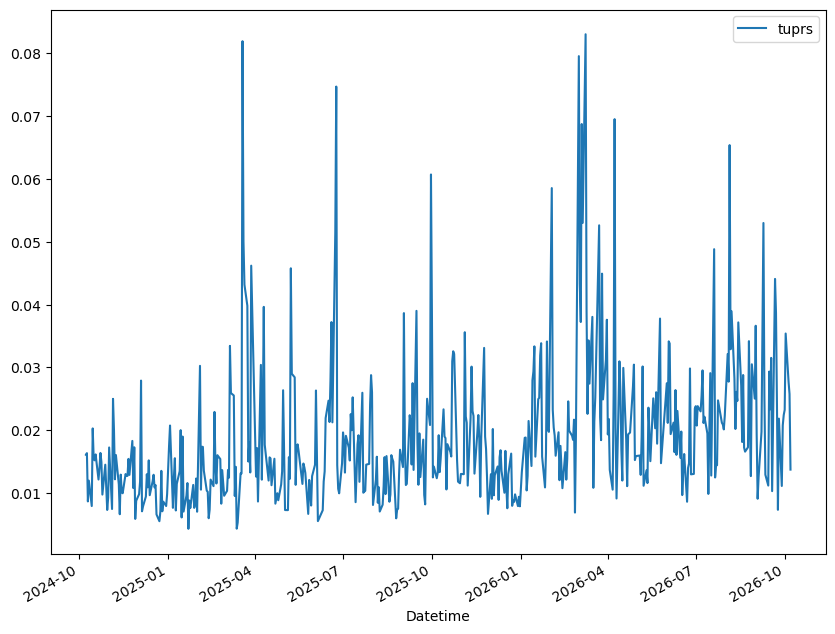

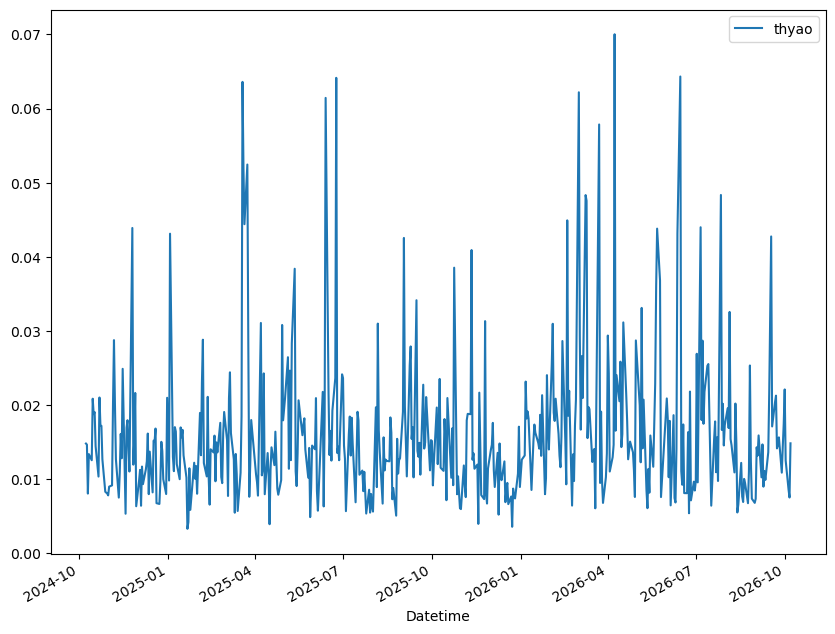

In [45]:
tuprs_rv.plot(y="daily_rv", figsize=(10,8), label="tuprs")
thyao_rv.plot(y="daily_rv", figsize=(10,8), label="thyao")
plt.show()

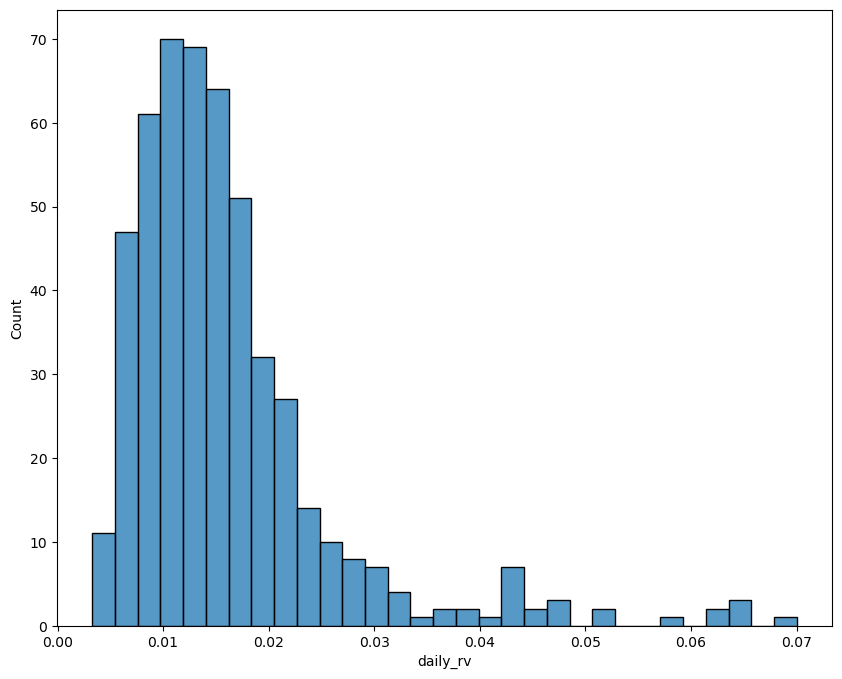

In [46]:
plt.figure(figsize=(10,8))
sns.histplot(data=thyao_rv, x="daily_rv")
plt.show()

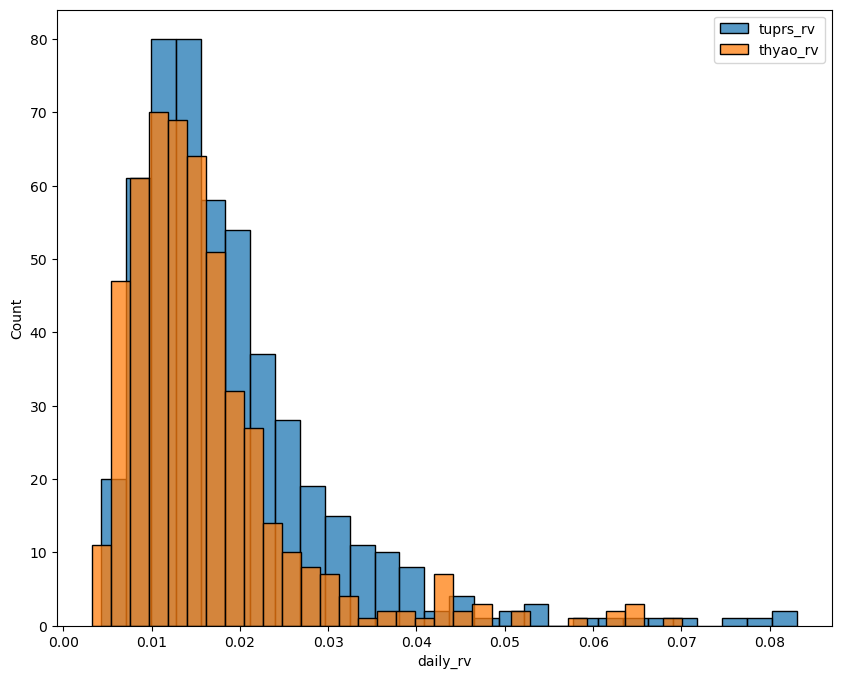

In [47]:
plt.figure(figsize=(10,8))
sns.histplot(data=tuprs_rv, x="daily_rv", label="tuprs_rv")
sns.histplot(data=thyao_rv, x="daily_rv", label="thyao_rv")
plt.legend()
plt.show()

In [48]:
thyao_rv["volatility_regime"].value_counts()

volatility_regime
high_volatility         171
low_volatility          167
neutral                 145
insufficient_history     19
Name: count, dtype: int64

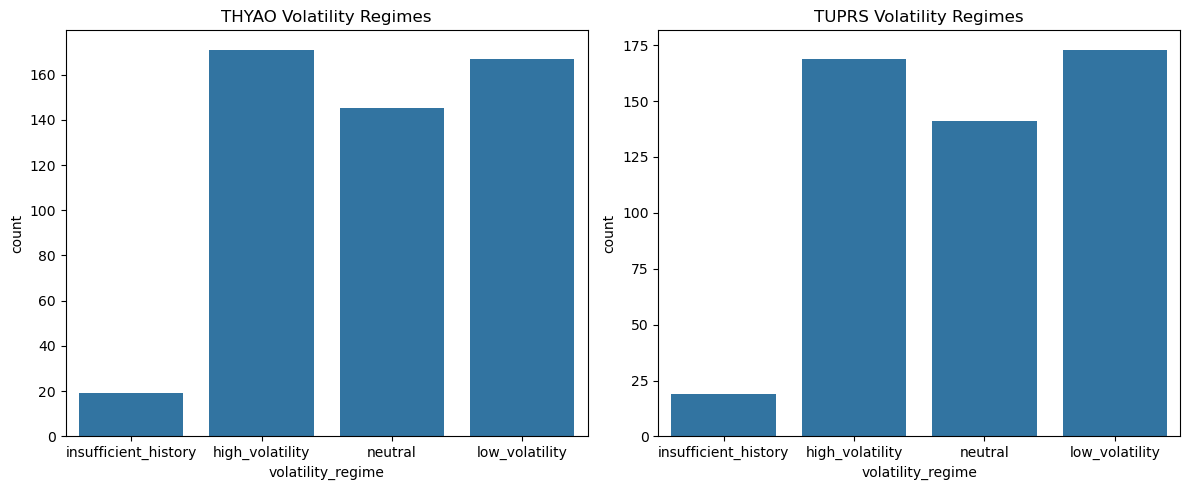

In [49]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.countplot(data=thyao_rv, x="volatility_regime")
plt.title("THYAO Volatility Regimes")

plt.subplot(1,2,2)
sns.countplot(data=tuprs_rv, x="volatility_regime")
plt.title("TUPRS Volatility Regimes")

plt.tight_layout()
plt.show()

In [50]:
yklsn_1h = yf.download("YKSLN.IS", interval="1h", period="max", multi_level_index=False)
yksln_rv = realized_volatility(yklsn_1h, interval="1D", rolling_period=20, timezone="Europe/Istanbul")

[*********************100%***********************]  1 of 1 completed


In [51]:
yksln_rv

,daily_rv,return,volatility_regime
Datetime,,,
2024-10-08 00:00:00+03:00,0.010210,-0.013407,insufficient_history
2024-10-09 00:00:00+03:00,0.031419,0.004552,insufficient_history
2024-10-10 00:00:00+03:00,0.042085,0.006268,insufficient_history
2024-10-11 00:00:00+03:00,0.041137,0.036445,insufficient_history
2024-10-14 00:00:00+03:00,0.026851,-0.037926,insufficient_history
...,...,...,...
2026-10-01 00:00:00+03:00,0.055781,0.006316,low_volatility
2026-10-02 00:00:00+03:00,0.042173,-0.003916,low_volatility
2026-10-05 00:00:00+03:00,0.096154,0.096154,neutral


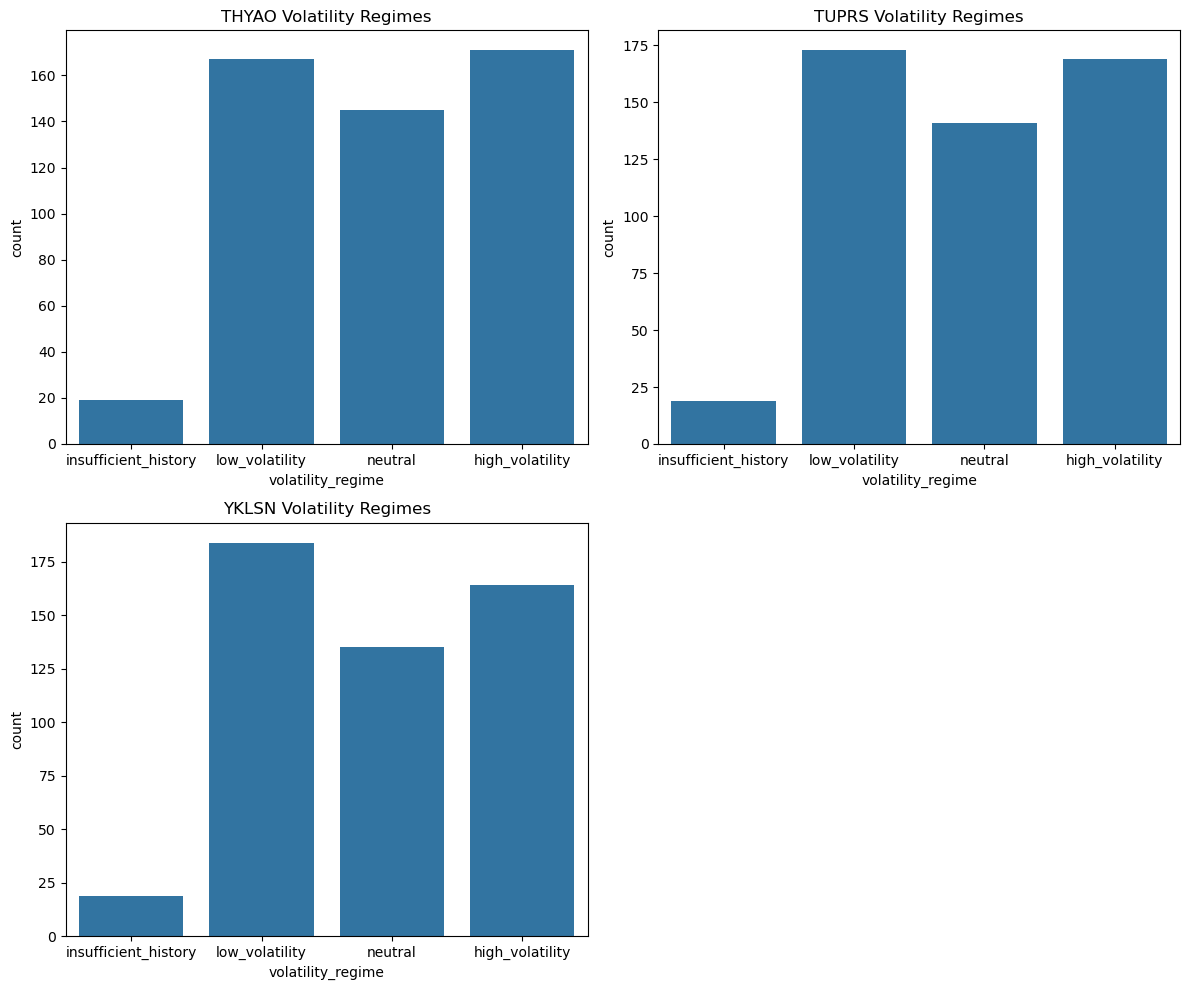

In [52]:
plt.figure(figsize=(12,10))
plt.subplot(2,2,1)
sns.countplot(data=thyao_rv, x="volatility_regime", order=["insufficient_history", "low_volatility", "neutral", "high_volatility"])
plt.title("THYAO Volatility Regimes")

plt.subplot(2,2,2)
sns.countplot(data=tuprs_rv, x="volatility_regime", order=["insufficient_history", "low_volatility", "neutral", "high_volatility"])
plt.title("TUPRS Volatility Regimes")


plt.subplot(2,2,3)
sns.countplot(data=yksln_rv, x="volatility_regime", order=["insufficient_history", "low_volatility", "neutral", "high_volatility"])
plt.title("YKLSN Volatility Regimes")

plt.tight_layout()
plt.show()

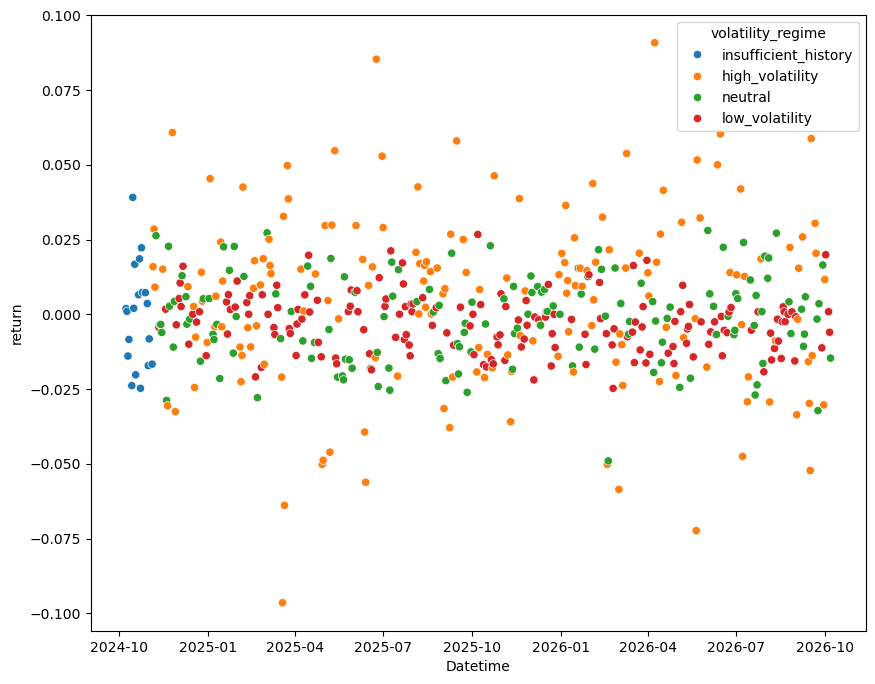

In [58]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=thyao_rv, x=thyao_rv.index, y="return", hue="volatility_regime")
plt.show()

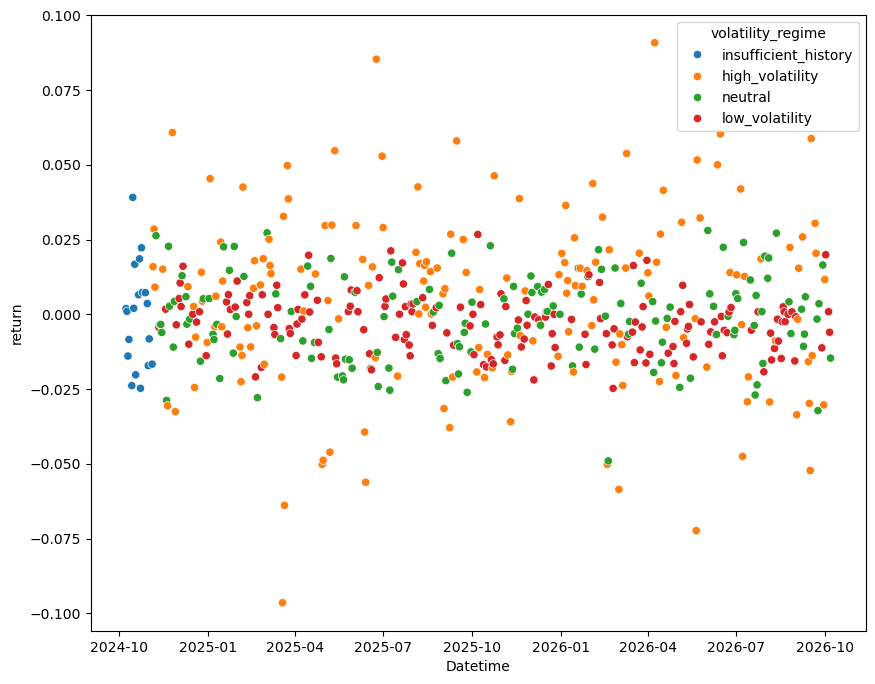

In [59]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=thyao_rv, x=tuprs_rv.index, y="return", hue="volatility_regime")
plt.show()

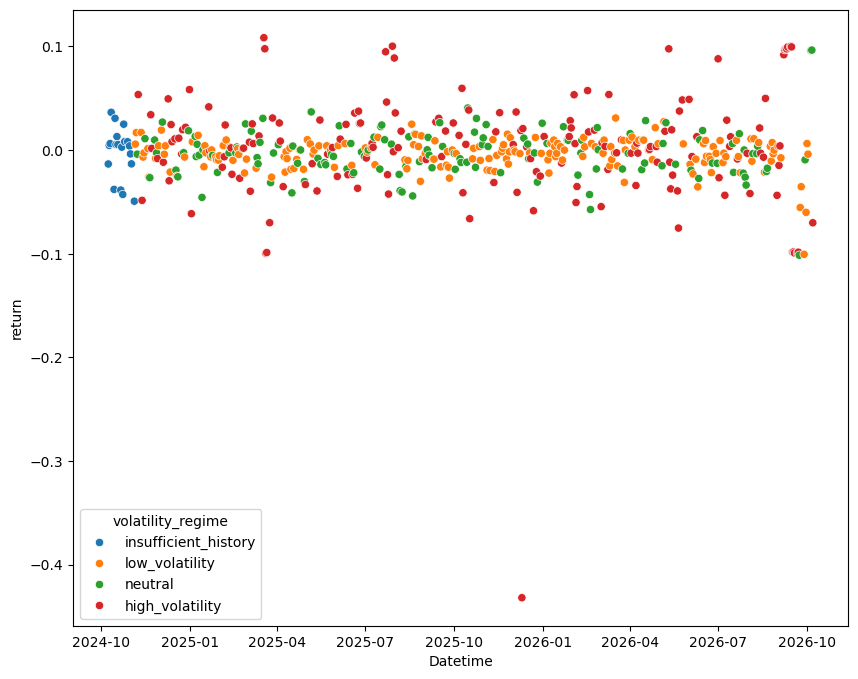

In [60]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=yksln_rv, x=thyao_rv.index, y="return", hue="volatility_regime")
plt.show()